<a href="https://colab.research.google.com/github/eshwar-7419/cads/blob/main/CARC_IDS_Phase1B_Corrected_Baseline_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1B — Corrected Baseline & Threshold Validation

## CARC-IDS/IPS research

This notebook corrects the Phase-1A validation problem.

### Why this notebook exists

The previous validation used the last 20% of the supplied training dataframe as validation. That segment contained **only attack samples**, making FPR undefined and causing the threshold-selection result to be invalid.

This notebook therefore:

1. verifies the actual class distribution across the temporal training sequence;
2. checks the supplied train/test structure;
3. creates a **stratified development/validation split** only from the training data for threshold/model selection;
4. compares original vs behavioral features;
5. performs threshold analysis on validation only;
6. freezes the selected model/threshold;
7. evaluates once on the untouched temporal test set;
8. saves a clean Phase-1 baseline for Phase 2.

### Important separation

**Phase 1B threshold validation is NOT the continual-learning experiment.**

We use stratification here only to obtain a valid threshold-selection set containing both benign and attack samples.

The original temporal test set remains untouched.

The next phase will separately construct the continual-learning stream.


In [1]:
# 1. Install dependencies
!pip -q install datasets lightgbm psutil joblib scikit-learn

print("Dependencies installed.")


Dependencies installed.


In [2]:
# 2. Imports and reproducibility
import os, time, json, shutil, warnings, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import joblib

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score, brier_score_loss
)
from sklearn.calibration import calibration_curve
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

BASE = Path("/content/carc_ids_phase1b")
RESULTS = BASE / "results"
ARTIFACTS = BASE / "artifacts"
for p in [RESULTS, ARTIFACTS]:
    p.mkdir(parents=True, exist_ok=True)

print("Working directory:", BASE)


Working directory: /content/carc_ids_phase1b


## 3. Load the exact dataset used in Phase 1

We keep:

```python
lacg030175/UNSW-NB15
```

with:

```python
"temporal"
```

configuration.

We do **not** switch to the random configuration.



In [3]:
# 3. Load exact Hugging Face dataset
ds = load_dataset(
    "lacg030175/UNSW-NB15",
    "temporal"
)

train_df = ds["train"].to_pandas()
test_df = ds["test"].to_pandas()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())


README.md:   0%|          | 0.00/5.32k [00:00<?, ?B/s]

temporal/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 12.7MB            

temporal/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

temporal/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 6.25MB            

temporal/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/175341 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/82332 [00:00<?, ? examples/s]

Train shape: (175341, 44)
Test shape : (82332, 44)

Columns:
['ackdat', 'attack_cat', 'ct_dst_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_flw_http_mthd', 'ct_ftp_cmd', 'ct_src_dport_ltm', 'ct_src_ltm', 'ct_srv_dst', 'ct_srv_src', 'ct_state_ttl', 'dbytes', 'Dintpkt', 'djit', 'dload', 'dloss', 'dmeansz', 'Dpkts', 'dtcpb', 'dttl', 'dur', 'dwin', 'is_ftp_login', 'is_sm_ips_ports', 'label', 'proto', 'rate', 'response_body_len', 'sbytes', 'service', 'Sintpkt', 'Sjit', 'sload', 'sloss', 'smeansz', 'Spkts', 'state', 'stcpb', 'sttl', 'swin', 'synack', 'tcprtt', 'trans_depth']


In [4]:
# 4. Basic integrity report

print("TRAIN label distribution")
train_counts = train_df["label"].value_counts(dropna=False).sort_index()
display(train_counts.rename("count").to_frame())

print("\nTEST label distribution")
test_counts = test_df["label"].value_counts(dropna=False).sort_index()
display(test_counts.rename("count").to_frame())

print("\nTRAIN attack proportion:", round(train_df["label"].mean(), 6))
print("TEST attack proportion :", round(test_df["label"].mean(), 6))

print("\nDuplicate rows:")
print("Train:", int(train_df.duplicated().sum()))
print("Test :", int(test_df.duplicated().sum()))


TRAIN label distribution


,count
label,
0,56000
1,119341



TEST label distribution


,count
label,
0,37000
1,45332



TRAIN attack proportion: 0.680622
TEST attack proportion : 0.5506

Duplicate rows:
Train: 67601
Test : 26387


## 5. Diagnose the actual ordering of the training data

This is the diagnostic that was missing from Phase 1A.

We divide the supplied training dataframe into 10 sequential segments and report the benign/attack composition of each segment.

This tells us whether dataframe position can safely be interpreted as a temporal validation boundary.

We will **not assume that it can** merely because the configuration is called `temporal`.


In [5]:
# 5. Sequential class-distribution diagnostic

n_segments = 10
segment_rows = []

for i, chunk in enumerate(np.array_split(train_df, n_segments), start=1):
    counts = chunk["label"].value_counts().to_dict()
    n = len(chunk)
    benign = int(counts.get(0, 0))
    attack = int(counts.get(1, 0))

    segment_rows.append({
        "segment": i,
        "rows": n,
        "benign": benign,
        "attack": attack,
        "benign_pct": benign / n if n else np.nan,
        "attack_pct": attack / n if n else np.nan
    })

segment_df = pd.DataFrame(segment_rows)
display(segment_df.round(4))

segment_df.to_csv(RESULTS / "training_sequence_class_distribution.csv", index=False)


,segment,rows,benign,attack,benign_pct,attack_pct
0,1,17535,17535,0,1.0000,0.0000
1,2,17534,17534,0,1.0000,0.0000
2,3,17534,12842,4692,0.7324,0.2676
3,4,17534,799,16735,0.0456,0.9544
4,5,17534,2438,15096,0.1390,0.8610
5,6,17534,2168,15366,0.1236,0.8764
6,7,17534,2684,14850,0.1531,0.8469
7,8,17534,0,17534,0.0000,1.0000
8,9,17534,0,17534,0.0000,1.0000
9,10,17534,0,17534,0.0000,1.0000


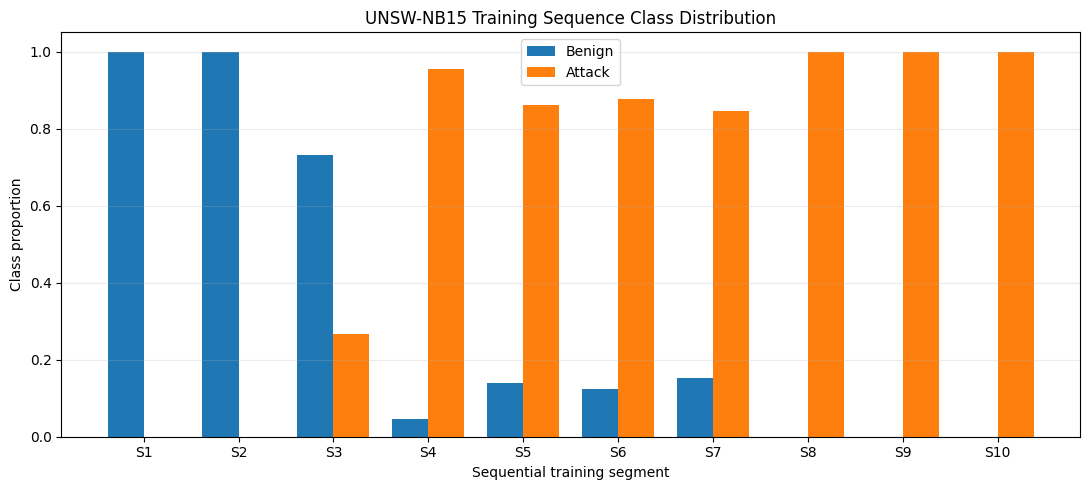

In [6]:
# 6. Plot sequential class distribution

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(segment_df))
width = 0.38

ax.bar(x - width/2, segment_df["benign_pct"], width, label="Benign")
ax.bar(x + width/2, segment_df["attack_pct"], width, label="Attack")

ax.set_xticks(x)
ax.set_xticklabels([f"S{i}" for i in segment_df["segment"]])
ax.set_xlabel("Sequential training segment")
ax.set_ylabel("Class proportion")
ax.set_title("UNSW-NB15 Training Sequence Class Distribution")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


## 7. Leakage-aware feature preparation

We remove:

- `label`;
- `attack_cat`;
- obvious identifiers if present.

`attack_cat` is not used because it directly represents attack categories and would leak target information into the binary detector.


In [7]:
# 7. Prepare features

TARGET = "label"

y = train_df[TARGET].astype(int).to_numpy()
y_test = test_df[TARGET].astype(int).to_numpy()

DROP_COLS = [
    c for c in ["label", "attack_cat", "id", "ID", "index"]
    if c in train_df.columns
]

X_raw = train_df.drop(columns=DROP_COLS, errors="ignore").copy()
X_test_raw = test_df.drop(columns=DROP_COLS, errors="ignore").copy()

print("Dropped columns:", DROP_COLS)
print("Raw train shape:", X_raw.shape)
print("Raw test shape :", X_test_raw.shape)


Dropped columns: ['label', 'attack_cat']
Raw train shape: (175341, 42)
Raw test shape : (82332, 42)


In [8]:
# 8. Behavioral feature engineering

def add_behavioral_features(df):
    out = df.copy()
    eps = 1e-6

    # UNSW-NB15 uses case-sensitive field names in some versions.
    def find_col(*names):
        for name in names:
            if name in out.columns:
                return name
        return None

    def num(*names):
        col = find_col(*names)
        if col is None:
            return pd.Series(0.0, index=out.index)
        return pd.to_numeric(out[col], errors="coerce").fillna(0.0)

    dur = num("dur")
    spkts = num("Spkts", "spkts")
    dpkts = num("Dpkts", "dpkts")
    sbytes = num("sbytes")
    dbytes = num("dbytes")

    total_packets = spkts + dpkts
    total_bytes = sbytes + dbytes

    out["beh_total_packets"] = total_packets
    out["beh_total_bytes"] = total_bytes
    out["beh_packets_per_sec"] = total_packets / (dur + eps)
    out["beh_bytes_per_sec"] = total_bytes / (dur + eps)
    out["beh_avg_packet_size"] = total_bytes / (total_packets + eps)
    out["beh_fwd_bwd_packet_ratio"] = (spkts + 1.0) / (dpkts + 1.0)
    out["beh_fwd_bwd_byte_ratio"] = (sbytes + 1.0) / (dbytes + 1.0)

    return out

X_fe = add_behavioral_features(X_raw)
X_test_fe = add_behavioral_features(X_test_raw)
X_test_fe = X_test_fe.reindex(columns=X_fe.columns)

BEHAVIORAL_COLS = [c for c in X_fe.columns if c not in X_raw.columns]

print("Original feature count:", len(X_raw.columns))
print("Feature-engineered count:", len(X_fe.columns))
print("Added features:")
for c in BEHAVIORAL_COLS:
    print(" -", c)


Original feature count: 42
Feature-engineered count: 49
Added features:
 - beh_total_packets
 - beh_total_bytes
 - beh_packets_per_sec
 - beh_bytes_per_sec
 - beh_avg_packet_size
 - beh_fwd_bwd_packet_ratio
 - beh_fwd_bwd_byte_ratio


# 9. Create a valid threshold-validation split

We use a **stratified split from the training data only**.

This is intentionally different from the failed Phase-1A approach.

Why?

Because threshold selection requires both classes:

\[
FPR = FP/(FP+TN)
\]

A validation set with no benign samples cannot estimate FPR.

### Important

This split is for:

- model comparison;
- threshold selection;
- probability calibration diagnostics.

It is **not** the continual-learning stream.

The original supplied test set remains untouched.


In [9]:
# 9. Stratified development/validation split
indices = np.arange(len(X_fe))

dev_idx, val_idx = train_test_split(
    indices,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

X_dev = X_fe.iloc[dev_idx].copy()
X_val = X_fe.iloc[val_idx].copy()

y_dev = y[dev_idx]
y_val = y[val_idx]

print("Development rows:", len(dev_idx))
print("Validation rows :", len(val_idx))
print("\nDevelopment label distribution:")
display(pd.Series(y_dev).value_counts().sort_index().rename("count").to_frame())

print("\nValidation label distribution:")
display(pd.Series(y_val).value_counts().sort_index().rename("count").to_frame())


Development rows: 140272
Validation rows : 35069

Development label distribution:


,count
0,44800
1,95472



Validation label distribution:


,count
0,11200
1,23869


In [10]:
# 10. Preprocessing helper

def make_preprocessor(X):
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_cols)
    ])

def fit_transform_sets(X_dev, X_val, X_test):
    pre = make_preprocessor(X_dev)

    Xd = pre.fit_transform(X_dev).astype(np.float32)
    Xv = pre.transform(X_val).astype(np.float32)
    Xt = pre.transform(X_test).astype(np.float32)

    return pre, Xd, Xv, Xt


# 11. Experiment A — Original features only

This establishes the baseline without our engineered behavioral features.


In [11]:
# 11. Original features

X_dev_orig = X_dev.drop(columns=BEHAVIORAL_COLS, errors="ignore")
X_val_orig = X_val.drop(columns=BEHAVIORAL_COLS, errors="ignore")
X_test_orig = X_test_fe.drop(columns=BEHAVIORAL_COLS, errors="ignore")

pre_orig, Xd_orig, Xv_orig, Xt_orig = fit_transform_sets(
    X_dev_orig, X_val_orig, X_test_orig
)

model_orig = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1
)

t0 = time.perf_counter()
model_orig.fit(Xd_orig, y_dev)
train_time_orig = time.perf_counter() - t0

p_val_orig = model_orig.predict_proba(Xv_orig)[:, 1]
p_test_orig = model_orig.predict_proba(Xt_orig)[:, 1]

print("Original model trained.")
print("Processed dimensions:", Xd_orig.shape)
print("Training time:", round(train_time_orig, 3), "sec")


Original model trained.
Processed dimensions: (140272, 192)
Training time: 22.003 sec


# 12. Experiment B — Original + Behavioral features


In [12]:
# 12. Feature-engineered model

X_test_fe = X_test_fe.reindex(columns=X_fe.columns)

pre_fe, Xd_fe, Xv_fe, Xt_fe = fit_transform_sets(
    X_dev, X_val, X_test_fe
)

model_fe = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1
)

t0 = time.perf_counter()
model_fe.fit(Xd_fe, y_dev)
train_time_fe = time.perf_counter() - t0

p_val_fe = model_fe.predict_proba(Xv_fe)[:, 1]
p_test_fe = model_fe.predict_proba(Xt_fe)[:, 1]

print("Feature-engineered model trained.")
print("Processed dimensions:", Xd_fe.shape)
print("Training time:", round(train_time_fe, 3), "sec")


Feature-engineered model trained.
Processed dimensions: (140272, 199)
Training time: 18.038 sec


In [13]:
# 13. Threshold-independent validation metrics

def prob_metrics(y_true, p):
    return {
        "roc_auc": roc_auc_score(y_true, p),
        "pr_auc": average_precision_score(y_true, p),
        "brier": brier_score_loss(y_true, p)
    }

prob_results = pd.DataFrame([
    {"model": "Original", **prob_metrics(y_val, p_val_orig)},
    {"model": "Original+Behavioral", **prob_metrics(y_val, p_val_fe)}
])

display(prob_results.round(6))


,model,roc_auc,pr_auc,brier
0,Original,0.993547,0.996943,0.029506
1,Original+Behavioral,0.993650,0.996993,0.029269


In [14]:
# 14. Threshold sweep on VALIDATION ONLY

thresholds = np.arange(0.05, 0.951, 0.05)

def threshold_sweep(y_true, probs, model_name):
    rows = []

    for threshold in thresholds:
        pred = (probs >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(
            y_true, pred, labels=[0, 1]
        ).ravel()

        rows.append({
            "model": model_name,
            "threshold": float(threshold),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
            "fpr": fp / (fp + tn) if (fp + tn) else np.nan,
            "tp": int(tp),
            "fp": int(fp),
            "tn": int(tn),
            "fn": int(fn)
        })

    return pd.DataFrame(rows)

val_thresholds = pd.concat([
    threshold_sweep(y_val, p_val_orig, "Original"),
    threshold_sweep(y_val, p_val_fe, "Original+Behavioral")
], ignore_index=True)

display(val_thresholds.round(6))


,model,threshold,precision,recall,f1,fpr,tp,fp,tn,fn
0,Original,0.05,0.914098,0.999958,0.955102,0.200268,23868,2243,8957,1
1,Original,0.10,0.915251,0.999916,0.955712,0.197321,23867,2210,8990,2
2,Original,0.15,0.918408,0.999749,0.957354,0.189286,23863,2120,9080,6
3,Original,0.20,0.920856,0.999288,0.958470,0.183036,23852,2050,9150,17
4,Original,0.25,0.924525,0.998157,0.959931,0.173661,23825,1945,9255,44
5,Original,0.30,0.931502,0.995894,0.962622,0.156071,23771,1748,9452,98
6,Original,0.35,0.939905,0.992710,0.965586,0.135268,23695,1515,9685,174
7,Original,0.40,0.948507,0.988563,0.968120,0.114375,23596,1281,9919,273
8,Original,0.45,0.956293,0.982655,0.969295,0.095714,23455,1072,10128,414
9,Original,0.50,0.963826,0.975617,0.969686,0.078036,23287,874,10326,582


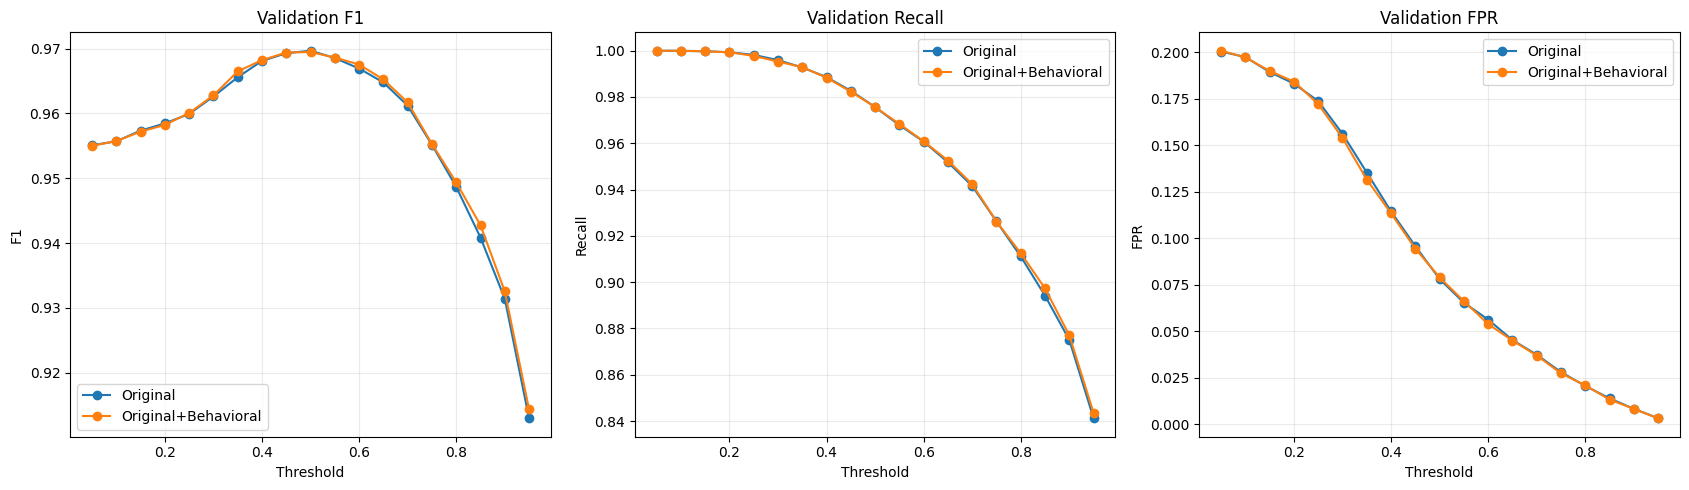

In [15]:
# 15. Plot validation trade-offs

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for name, g in val_thresholds.groupby("model"):
    axes[0].plot(g.threshold, g.f1, marker="o", label=name)
    axes[1].plot(g.threshold, g.recall, marker="o", label=name)
    axes[2].plot(g.threshold, g.fpr, marker="o", label=name)

axes[0].set_title("Validation F1")
axes[1].set_title("Validation Recall")
axes[2].set_title("Validation FPR")

for ax in axes:
    ax.set_xlabel("Threshold")
    ax.grid(alpha=0.25)
    ax.legend()

axes[0].set_ylabel("F1")
axes[1].set_ylabel("Recall")
axes[2].set_ylabel("FPR")

plt.tight_layout()
plt.show()


# 16. Threshold-selection policy

We do not select a threshold using the final test set.

We report two useful validation operating points:

### A. F1-optimal threshold

Maximizes validation F1.

### B. FPR-constrained threshold

Uses a **10% FPR budget** as an initial operational constraint and selects the highest-recall feasible threshold.

The 10% value is a tunable research operating point, not a universal IDS standard.

If no threshold satisfies the budget, the notebook reports that explicitly.


In [16]:
# 16. Select validation thresholds

FPR_BUDGET = 0.10

selection = []

for model_name, g in val_thresholds.groupby("model"):
    # F1-optimal
    f1_row = g.loc[g.f1.idxmax()]

    # Constrained
    feasible = g[g.fpr <= FPR_BUDGET].copy()

    if len(feasible):
        feasible = feasible.sort_values(
            ["recall", "precision", "threshold"],
            ascending=[False, False, False]
        )
        constrained = feasible.iloc[0]
    else:
        constrained = None

    selection.append({
        "model": model_name,
        "f1_opt_threshold": f1_row.threshold,
        "f1_opt_f1": f1_row.f1,
        "f1_opt_recall": f1_row.recall,
        "f1_opt_fpr": f1_row.fpr,
        "constrained_threshold": None if constrained is None else constrained.threshold,
        "constrained_f1": None if constrained is None else constrained.f1,
        "constrained_recall": None if constrained is None else constrained.recall,
        "constrained_precision": None if constrained is None else constrained.precision,
        "constrained_fpr": None if constrained is None else constrained.fpr
    })

selection_df = pd.DataFrame(selection)
display(selection_df.round(6))


,model,f1_opt_threshold,f1_opt_f1,f1_opt_recall,f1_opt_fpr,constrained_threshold,constrained_f1,constrained_recall,constrained_precision,constrained_fpr
0,Original,0.5,0.969686,0.975617,0.078036,0.45,0.969295,0.982655,0.956293,0.095714
1,Original+Behavioral,0.5,0.969484,0.975617,0.078929,0.45,0.969404,0.982278,0.956862,0.094375


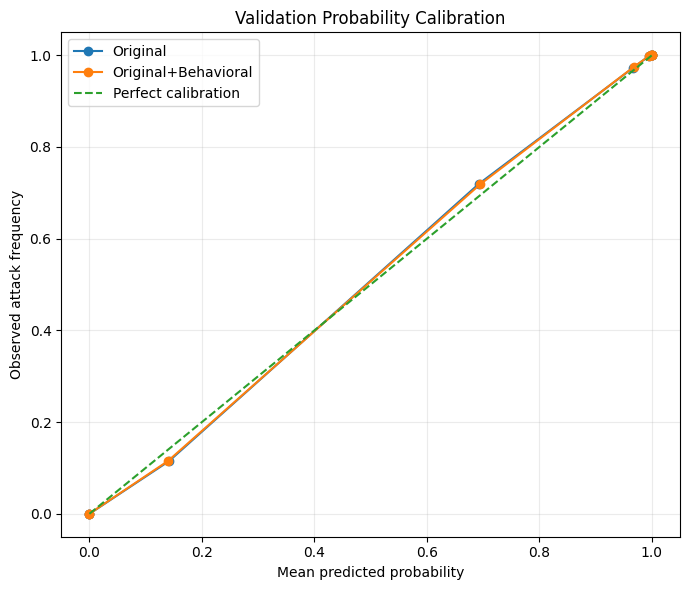

In [17]:
# 17. Calibration curves on validation

fig, ax = plt.subplots(figsize=(7, 6))

for name, probs in [
    ("Original", p_val_orig),
    ("Original+Behavioral", p_val_fe)
]:
    frac_pos, mean_pred = calibration_curve(
        y_val, probs, n_bins=10, strategy="quantile"
    )
    ax.plot(mean_pred, frac_pos, marker="o", label=name)

ax.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed attack frequency")
ax.set_title("Validation Probability Calibration")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


# 18. Freeze the feature set and threshold

For the main baseline, we select the feature set according to **validation F1**, then use the **FPR-constrained threshold if one exists**.

This decision is made entirely from the development/validation data.

The final temporal test set remains untouched.


In [18]:
# 18. Freeze model/threshold from validation only

best_model_name = selection_df.loc[
    selection_df["f1_opt_f1"].idxmax(), "model"
]

row = selection_df[selection_df["model"] == best_model_name].iloc[0]

if pd.notna(row["constrained_threshold"]):
    frozen_threshold = float(row["constrained_threshold"])
    threshold_policy = "validation_FPR_constrained_10pct"
else:
    frozen_threshold = float(row["f1_opt_threshold"])
    threshold_policy = "validation_F1_optimal_fallback"

if best_model_name == "Original":
    frozen_model = model_orig
    frozen_test_probs = p_test_orig
else:
    frozen_model = model_fe
    frozen_test_probs = p_test_fe

print("Frozen model:", best_model_name)
print("Frozen threshold:", frozen_threshold)
print("Threshold policy:", threshold_policy)


Frozen model: Original
Frozen threshold: 0.45
Threshold policy: validation_FPR_constrained_10pct


In [19]:
# 19. Final temporal test evaluation

final_test_pred = (frozen_test_probs >= frozen_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test, final_test_pred, labels=[0,1]
).ravel()

final_result = {
    "dataset": "lacg030175/UNSW-NB15",
    "config": "temporal",
    "feature_set": best_model_name,
    "threshold": frozen_threshold,
    "threshold_policy": threshold_policy,
    "test_accuracy": accuracy_score(y_test, final_test_pred),
    "test_precision": precision_score(y_test, final_test_pred, zero_division=0),
    "test_recall": recall_score(y_test, final_test_pred, zero_division=0),
    "test_f1": f1_score(y_test, final_test_pred, zero_division=0),
    "test_fpr": fp / (fp + tn) if (fp + tn) else np.nan,
    "test_roc_auc": roc_auc_score(y_test, frozen_test_probs),
    "test_pr_auc": average_precision_score(y_test, frozen_test_probs),
    "test_brier": brier_score_loss(y_test, frozen_test_probs),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp)
}

display(pd.DataFrame([final_result]).T.rename(columns={0:"value"}))

print("\nFinal temporal test classification report:")
print(classification_report(
    y_test, final_test_pred, digits=4, zero_division=0
))


,value
dataset,lacg030175/UNSW-NB15
config,temporal
feature_set,Original
threshold,0.45
threshold_policy,validation_FPR_constrained_10pct
test_accuracy,0.863953
test_precision,0.807271
test_recall,0.989036
test_f1,0.888957
test_fpr,0.289297



Final temporal test classification report:
              precision    recall  f1-score   support

           0     0.9815    0.7107    0.8244     37000
           1     0.8073    0.9890    0.8890     45332

    accuracy                         0.8640     82332
   macro avg     0.8944    0.8499    0.8567     82332
weighted avg     0.8855    0.8640    0.8600     82332



In [20]:
# 20. Save all Phase-1B outputs

segment_df.to_csv(
    RESULTS / "training_sequence_class_distribution.csv",
    index=False
)

prob_results.to_csv(
    RESULTS / "validation_probability_metrics.csv",
    index=False
)

val_thresholds.to_csv(
    RESULTS / "validation_threshold_sweep.csv",
    index=False
)

selection_df.to_csv(
    RESULTS / "threshold_selection.csv",
    index=False
)

pd.DataFrame([final_result]).to_csv(
    RESULTS / "phase1b_final_test_result.csv",
    index=False
)

joblib.dump(
    frozen_model,
    ARTIFACTS / "phase1b_frozen_model.joblib"
)

with open(ARTIFACTS / "phase1b_protocol.json", "w") as f:
    json.dump({
        "dataset": "lacg030175/UNSW-NB15",
        "config": "temporal",
        "validation_method": "stratified 80/20 split of supplied training data",
        "final_test_used_for_threshold_selection": False,
        "fpr_budget": FPR_BUDGET,
        "selected_model": best_model_name,
        "selected_threshold": frozen_threshold,
        "threshold_policy": threshold_policy,
        "seed": SEED
    }, f, indent=2)

bundle = shutil.make_archive(
    str(BASE / "phase1b_artifacts"),
    "zip",
    root_dir=BASE
)

print("Saved bundle:", bundle)
print("\nKey outputs:")
for p in sorted(RESULTS.glob("*")):
    print(" -", p)


Saved bundle: /content/carc_ids_phase1b/phase1b_artifacts.zip

Key outputs:
 - /content/carc_ids_phase1b/results/phase1b_final_test_result.csv
 - /content/carc_ids_phase1b/results/threshold_selection.csv
 - /content/carc_ids_phase1b/results/training_sequence_class_distribution.csv
 - /content/carc_ids_phase1b/results/validation_probability_metrics.csv
 - /content/carc_ids_phase1b/results/validation_threshold_sweep.csv


# 21. Phase-1B completion criteria

Phase 1B is considered complete when:

- [x] training sequence class distribution is documented;
- [x] validation contains both benign and attack samples;
- [x] original vs behavioral features are compared;
- [x] threshold is selected without using the final test set;
- [x] final temporal test is evaluated once;
- [x] F1, recall, FPR and resource-independent probability metrics are recorded.

### Next step

Once this notebook is run and its results are inspected, **freeze the baseline**.

Then move to:

# Phase 2 — Continual Learning Benchmark

We will construct:

1. Static model
2. Naive continual update
3. Replay
4. EWC
5. Proposed Resource-Aware Adaptation Utility

and evaluate new-threat detection, historical retention, forgetting, FPR, update count, training cost and memory.
